# 02 · Transforms v2 validation

Validate that torchvision transforms v2 jointly transform image and mask before
the `PeanutDataset` is written. Four things to confirm:

- `tv_tensors.Mask` keeps integer class indices, with no interpolation to phantom values
- a random crop lands on the same region in image and mask
- normalization applies to the image only and leaves the mask untouched
- the val/test path returns the full 960×720 frame without a crop

Whatever holds here becomes a fixed decision for the implementation in
`src/cropweed_seg/`. Sample `0003` is used throughout because it contains both
crop and weed, so alignment can be checked on both classes at once.

### Load one sample

Read a single image and its converted mask, and confirm the shapes and classes
match what notebook 01 established: image 960×720, mask (720, 960) uint8 with
classes {0, 1, 2}.

In [2]:
from pathlib import Path

import numpy as np
import torch
from PIL import Image as PILImage

ROOT = Path.cwd().parent
assert (ROOT / "pyproject.toml").exists(), f"ROOT mal resuelto: {ROOT}"

RAW_IMAGES = ROOT / "data" / "raw" / "images"
PROCESSED_LABELS = ROOT / "data" / "processed" / "labels"

# 0003 has both crop and weed, good for checking alignment of both classes
stem = "0003"
image_pil = PILImage.open(RAW_IMAGES / f"{stem}.jpg")
mask_np = np.asarray(PILImage.open(PROCESSED_LABELS / f"{stem}.png"))

print("image size (WxH):", image_pil.size)
print("mask shape (HxW):", mask_np.shape, "dtype:", mask_np.dtype)
print("mask classes:", np.unique(mask_np))

image size (WxH): (960, 720)
mask shape (HxW): (720, 960) dtype: uint8
mask classes: [0 1 2]


### Wrap in tv_tensors and crop jointly

The image goes through `F.to_image`, the mask through
`F.pil_to_tensor(...).squeeze(0)`. Loading the mask straight from Pillow to a
tensor avoids the read-only-memory warning that `torch.from_numpy` raises on a
numpy view, and the squeeze drops the singleton channel so the mask stays (H, W).
Both load paths go through Pillow, with no detour through numpy.

Passing image and mask through the same transform call is the point: the crop
parameters are sampled once and applied to both. The check that matters is
whether the mask keeps integer classes after the crop. A float or an unexpected
value would mean smoothing interpolation, which must not happen on a label map.

In [5]:
from torchvision import tv_tensors
from torchvision.transforms import v2
from torchvision.transforms.v2 import functional as F

# Wrap in tv_tensors. Image expects CHW; F.to_image handles the HWC->CHW + tensor.
img_tv = F.to_image(image_pil)                       # uint8 tensor, shape (3, 720, 960)
mask_tv = tv_tensors.Mask(F.pil_to_tensor(PILImage.open(PROCESSED_LABELS / f"{stem}.png")).squeeze(0)) # int tensor, shape (720, 960)

print("img_tv:", img_tv.shape, img_tv.dtype, type(img_tv).__name__)
print("mask_tv:", mask_tv.shape, mask_tv.dtype, type(mask_tv).__name__)

# Apply ONE random crop jointly. Passing both through the same call is the
# whole point: the crop parameters are sampled once and applied to both.
cropper = v2.RandomCrop(size=(512, 512))
img_c, mask_c = cropper(img_tv, mask_tv)

print("\nafter crop:")
print("img_c:", img_c.shape, type(img_c).__name__)
print("mask_c:", mask_c.shape, type(mask_c).__name__)
print("mask classes after crop:", torch.unique(mask_c).tolist())

img_tv: torch.Size([3, 720, 960]) torch.uint8 Image
mask_tv: torch.Size([720, 960]) torch.uint8 Mask

after crop:
img_c: torch.Size([3, 512, 512]) Image
mask_c: torch.Size([512, 512]) Mask
mask classes after crop: [0, 1, 2]


Types survive the crop: image stays `Image`, mask stays `Mask`, both at 512×512.
Classes after the crop are still {0, 1, 2}, so v2 uses nearest-neighbor on the
mask and introduces no phantom indices. The core uncertainty of this step is
resolved.

### Visual alignment check

Numbers say the crop is joint; eyes confirm it. Three random crops, image next to
mask. In each row the plants in the photo must sit exactly where the green and red
regions sit in the mask.

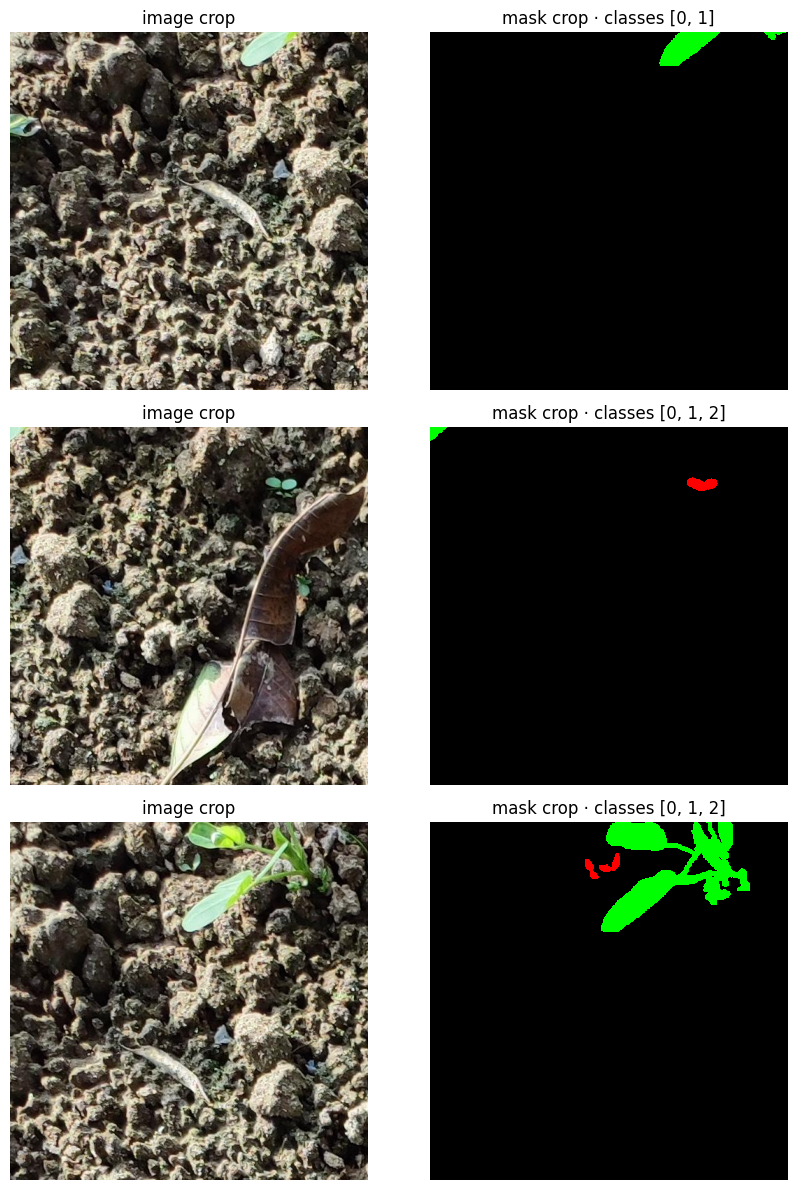

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

INDEX_CMAP = ListedColormap(["black", "lime", "red"])

# Re-crop a few times to see different regions; alignment must hold every time
fig, axes = plt.subplots(3, 2, figsize=(9, 12))
for row in axes:
    img_c, mask_c = cropper(img_tv, mask_tv)
    # image tensor is CHW uint8; matplotlib wants HWC
    row[0].imshow(img_c.permute(1, 2, 0))
    row[0].set_title("image crop")
    row[1].imshow(mask_c, cmap=INDEX_CMAP, vmin=0, vmax=2, interpolation="nearest")
    row[1].set_title(f"mask crop · classes {torch.unique(mask_c).tolist()}")
    for ax in row:
        ax.axis("off")
plt.tight_layout()
plt.show()

Alignment holds in all three rows. The third is the clearest: the large plant
top-right of the photo maps to the green blob, and the small weed beside it maps
to the red speck. The first row also shows the empty-crop case in action, mostly
soil with a sliver of crop in the corner. Across three draws, two already caught
all three classes, which supports ignoring empty crops in the baseline.

### Full transform, including normalization

Add float scaling and ImageNet normalization to the crop. Two things to verify:
the image leaves the [0, 1] range, which is what normalization does, and the mask
comes out unchanged. ImageNet stats are used because the baseline backbone is
pretrained on ImageNet, so the input has to match the distribution that backbone
expects. These stats are not meant to describe this dataset.

In [7]:
# Full train transform: crop -> float scaling -> ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = v2.Compose([
    v2.RandomCrop(size=(512, 512)),
    v2.ToDtype(torch.float32, scale=True),   # uint8 [0,255] -> float [0,1]
    v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),  # image only
])

img_out, mask_out = train_tf(img_tv, mask_tv)

print("image:", img_out.dtype, type(img_out).__name__)
print(f"  per-channel mean: {img_out.mean(dim=(1, 2)).tolist()}")
print(f"  min {img_out.min():.3f}, max {img_out.max():.3f}")
print()
print("mask:", mask_out.dtype, type(mask_out).__name__)
print("  classes:", torch.unique(mask_out).tolist())
print("  unchanged vs a bare crop?", "see values above")

image: torch.float32 Image
  per-channel mean: [-0.4627423882484436, -0.4437180757522583, -0.4532168507575989]
  min -2.118, max 2.640

mask: torch.uint8 Mask
  classes: [0, 1, 2]
  unchanged vs a bare crop? see values above


## Conclusions

All four points hold:

- the mask keeps integer classes {0, 1, 2} through the crop and through the full Compose
- the crop is applied jointly, confirmed visually on both classes
- normalization moves the image to [-2.118, 2.640] and leaves the mask as uint8
- per-channel means near -0.45 reflect a mostly-soil crop, darker than the ImageNet mean

Fixed decisions for `PeanutDataset`:

- load image with `F.to_image`, mask with `F.pil_to_tensor(...).squeeze(0)`, no numpy
- `build_transforms(split)` returns the Compose: crop on train, no crop on val/test
- normalize with ImageNet stats, applied to the image only
- val/test uses full 960×720 frames; batching works because every image is the same size
- empty crops are tolerated in the baseline, revisited only if weed learns slowly